# Phase 6: Convolutional Neural Network

In this phase, I will build a Convolutional Neural Network using TensorFlow/Keras.

The main goals of this phase are:

- Load the MNIST dataset
- Normalize pixel values from 0–255 to 0–1
- Reshape images for CNN input
- Build a CNN architecture
- Train the CNN model
- Evaluate the CNN model accuracy
- Compare the CNN with the Logistic Regression baseline and dense neural network

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_norm.reshape(-1, 28, 28, 1)

In [4]:
print("CNN training shape:", x_train_cnn.shape)
print("CNN test shape:", x_test_cnn.shape)

print("Minimum pixel value:", x_train_cnn.min())
print("Maximum pixel value:", x_train_cnn.max())

CNN training shape: (60000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [5]:
cnn_model = Sequential ([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

c:\Users\User\Desktop\handwritten-digit-recognition\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
cnn_model.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=["accuracy"]
)

In [8]:
cnn_history=cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9412 - loss: 0.1949 - val_accuracy: 0.9686 - val_loss: 0.1044
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9807 - loss: 0.0647 - val_accuracy: 0.9812 - val_loss: 0.0635
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9874 - loss: 0.0424 - val_accuracy: 0.9827 - val_loss: 0.0586
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9906 - loss: 0.0313 - val_accuracy: 0.9834 - val_loss: 0.0576
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9930 - loss: 0.0225 - val_accuracy: 0.9853 - val_loss: 0.0540


In [9]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(x_test_cnn, y_test)

print("CNN test loss:", cnn_test_loss)
print("CNN test accuracy:", cnn_test_accuracy)
print("CNN test accuracy (%):", cnn_test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9860 - loss: 0.0445
CNN test loss: 0.04452794790267944
CNN test accuracy: 0.9860000014305115
CNN test accuracy (%): 98.60000014305115


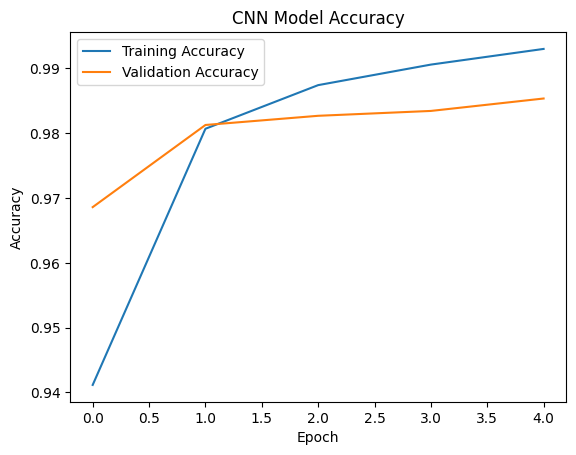

In [10]:
plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Model Accuracy")
plt.legend()
plt.show()

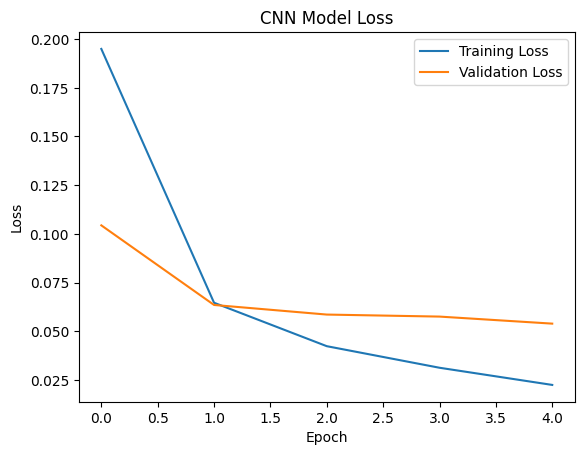

In [11]:
plt.plot(cnn_history.history["loss"], label="Training Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Model Loss")
plt.legend()
plt.show()

In [12]:
cnn_y_prob = cnn_model.predict(x_test_cnn)
cnn_y_pred = np.argmax(cnn_y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [13]:
print("First 10 true labels:")
print(y_test[:10])

print("First 10 CNN predicted labels:")
print(cnn_y_pred[:10])

First 10 true labels:
[7 2 1 0 4 1 4 9 5 9]
First 10 CNN predicted labels:
[7 2 1 0 4 1 4 9 5 9]


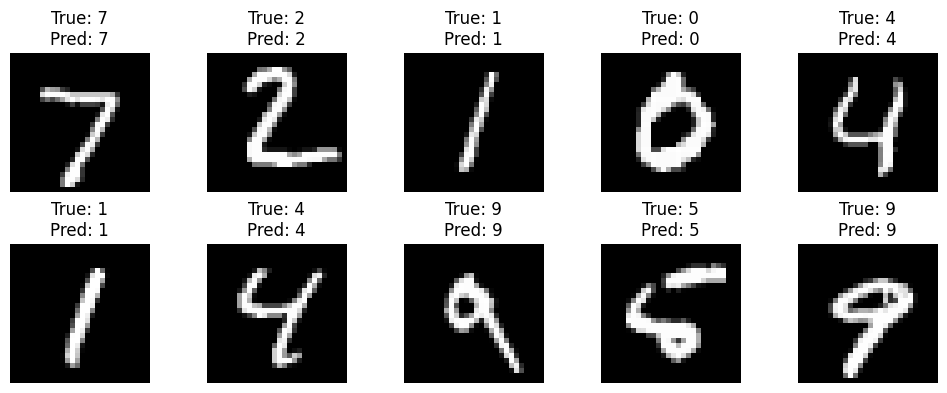

In [14]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"True: {y_test[i]}\nPred: {cnn_y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN Model Predictions

The images above show the first 10 test examples from the MNIST dataset.

For each image:

- `True` represents the correct label from the dataset
- `Pred` represents the label predicted by the Convolutional Neural Network

This visual check helps confirm whether the CNN is correctly recognizing handwritten digits.

## Phase 6 Summary: Convolutional Neural Network

In this phase, I built and trained a Convolutional Neural Network using TensorFlow/Keras.

### Completed Tasks

- Loaded the MNIST dataset
- Normalized pixel values from 0–255 to 0–1
- Reshaped images from `(28, 28)` to `(28, 28, 1)` for CNN input
- Built a CNN architecture using:
  - `Conv2D`
  - `MaxPooling2D`
  - `Flatten`
  - `Dense`
- Compiled the CNN using:
  - Adam optimizer
  - Sparse categorical crossentropy loss
  - Accuracy metric
- Trained the CNN for 5 epochs
- Evaluated the CNN on the test set
- Plotted training and validation accuracy
- Plotted training and validation loss
- Made predictions on the test set
- Visualized CNN predictions on sample test images

### Key Observation

The CNN is better suited for image recognition than the Logistic Regression baseline and the dense neural network because it preserves the spatial structure of the image.

Instead of treating the image as only a long vector of pixels, the CNN uses convolutional filters to detect local patterns such as edges, curves, and shapes.

This makes CNNs especially useful for computer vision tasks like handwritten digit recognition.